# Titanic Data Peprocessing Step by Step
### Support me with an upvote if you find it useful! 👍
## Intro
 I'm talking just from *my experience on Titanic* so the following may not be true for you, so be cautious.

 - "Has_Cabin" feature does not help. I engineered a feature with 0 if a passenger has no Cabin (NaN) and 1 if he got one may make sense as cabin data of 1st class passengers was found (IRL) on the body of steward Herbert Cave, so I tried it. But that doesn't seem to help.
 - "Deck" feature does not help. Based on letters found in Cabin column we may engineer a Deck feature, indicating which deck (A - G, T or U for Unknown) the passenger was on. But it's rather noisy, it doesn't help the score.
 - "Embarked" does not help, I have no idea why people even include it in their kernels. It has no impact on survival chances.
 - *Edit*: actually certain algorithms may perform better if you turn categorical features into ordinal ones (like turning Pclass to Pclass_1, Pclass_2 and Pclass_3 features with possible values {0, 1}). Pros are higher accuracy in certain cases, cons are - you lose relation between Pclasses (meaning the algorithm will think those are independent, unordered classes, when in fact they are ordered - Pclass=1 is "better" than Pclass=3) and you add dimensions which is not always good because of the curse of dimensionality. In my specific case turning Pclass into 3 features did not help, but as I learned it's a good idea to try both approaches and see what's better in your case.
 - I don't know about feature scaling in R, maybe R methods scale them by default? If not, and if you're using R, try scaling, it may help.
 - There is not much sence in scaling features that are already 0 or 1 like Sex, but for now I scale them all. You can try to pick features for scaling. If you don't use bins (if you use Age or Fare "as is"), scaling may help to boost your score a bit, try it.


## Workflow goals

The data science solutions workflow solves for seven major goals.

**Classifying.** We may want to classify or categorize our samples. We may also want to understand the implications or correlation of different classes with our solution goal.

**Correlating.** One can approach the problem based on available features within the training dataset. Which features within the dataset contribute significantly to our solution goal? Statistically speaking is there a [correlation](https://en.wikiversity.org/wiki/Correlation) among a feature and solution goal? As the feature values change does the solution state change as well, and visa-versa? This can be tested both for numerical and categorical features in the given dataset. We may also want to determine correlation among features other than survival for subsequent goals and workflow stages. Correlating certain features may help in creating, completing, or correcting features.

**Converting.** For modeling stage, one needs to prepare the data. Depending on the choice of model algorithm one may require all features to be converted to numerical equivalent values. So for instance converting text categorical values to numeric values.

**Completing.** Data preparation may also require us to estimate any missing values within a feature. Model algorithms may work best when there are no missing values.

**Correcting.** We may also analyze the given training dataset for errors or possibly innacurate values within features and try to corrent these values or exclude the samples containing the errors. One way to do this is to detect any outliers among our samples or features. We may also completely discard a feature if it is not contribting to the analysis or may significantly skew the results.

**Creating.** Can we create new features based on an existing feature or a set of features, such that the new feature follows the correlation, conversion, completeness goals.

**Charting.** How to select the right visualization plots and charts depending on nature of the data and the solution goals.

# Part 1 : Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import math
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# Part 2 : Importing & Exploring Data

In [2]:
Titanic = pd.read_csv("../input/titanic/train.csv")
test = pd.read_csv("../input/titanic/test.csv")


In [3]:
Titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**Data Dictionary**

* survived: 0 = No, 1 = Yes
* pclass:Ticket Class 1=1st, 2=2nd, 3=3rd
* SibSp: # of Sibilings/Spouses aboard the titanic (0 mentions neither have have Spuose nor Sibilings)
* parch: # of parents/children aboard the titanic
* ticket: Ticket number
* Cabin: Cabin Number
* embarked: Port of Embarkation C= Cherboug, S= Southamptom, Q = Queenstown

In [4]:
Titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
Titanic.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
Titanic.shape

(891, 12)

In [7]:
Titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


We've got a sense of our variables, their class type, and the first few observations of each. We know we're working with 1309 observations of 12 variables. In which 891 observations are from train data set, and 418 observations are from test data set. When separate the variables by type, we have ordinal variable PassengerId, lable variable Name and Ticket, numeric variables such as Age, SibSp, Parch, Fare, and categorical variables like Survived ,Pclass, Sex ,Cabin, and Embarked.

In [8]:
Titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
Titanic.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Petroff, Mr. Pastcho (""Pentcho"")",male,347082,G6,S
freq,1,577,7,4,644


# Part 3 : Data Analyze by pivoting features

In [10]:
Titanic[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [11]:
Titanic[["Sex" , "Survived"]].groupby(["Sex"] , as_index = False).mean().sort_values(by="Survived" , ascending = False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [12]:
Titanic[["Parch" , "Survived"]].groupby(["Parch"] , as_index = False) .mean().sort_values(by="Survived" , ascending = False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


In [13]:
Titanic[['Embarked', 'Survived']].groupby(['Embarked'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


In [14]:
Titanic[['SibSp', 'Survived']].groupby(['SibSp'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


# Part 4 : Data Analyze by visualization Method

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f155ee2de90>,
      dtype=object)

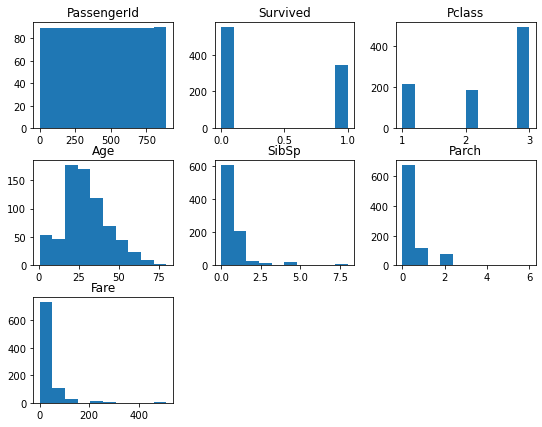

In [15]:

Titanic.hist(bins=10,figsize=(9,7),grid=False)

In [16]:
print("No of Passengers in original data:  " , str(len(Titanic.index)))

No of Passengers in original data:   891


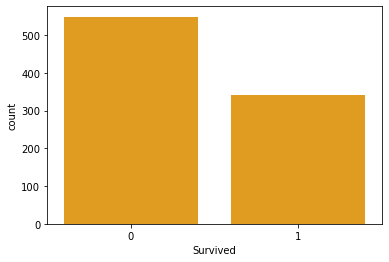

In [17]:
sns.countplot(x="Survived" , data=Titanic , color="orange")

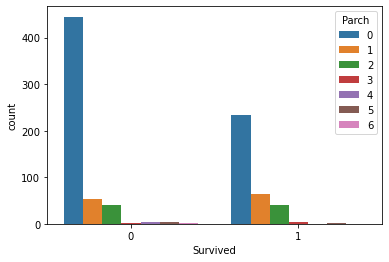

In [18]:
sns.countplot(x="Survived", hue="Parch",data=Titanic)

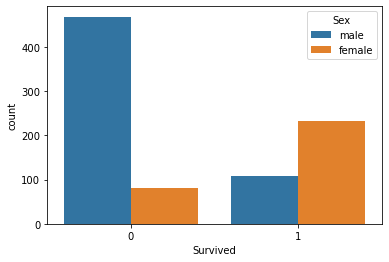

In [19]:
sns.countplot(x="Survived" ,hue="Sex" , data=Titanic )



We can see from the Countplot above that female's survival rate is greater than male's.


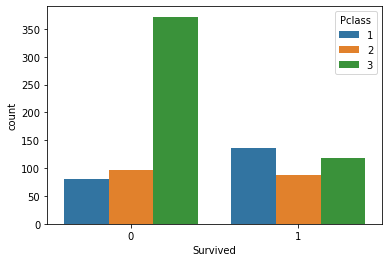

In [20]:
sns.countplot(x="Survived" ,hue="Pclass" , data=Titanic )

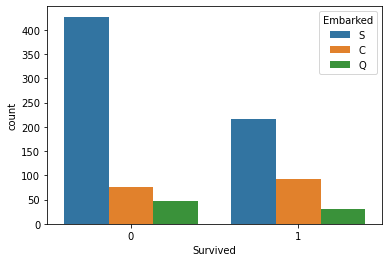

In [21]:
sns.countplot(x="Survived" ,hue="Embarked" , data=Titanic )

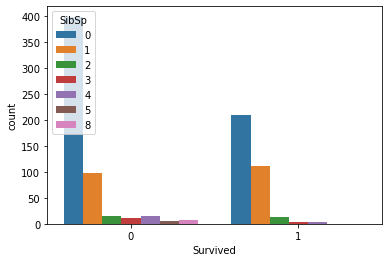

In [22]:
sns.countplot(x="Survived", hue="SibSp",data=Titanic)

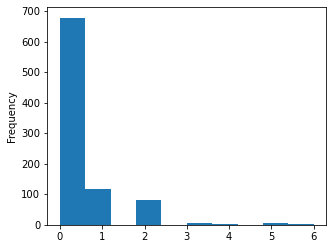

In [23]:
Titanic["Parch"].plot.hist( figsize=(5,4))

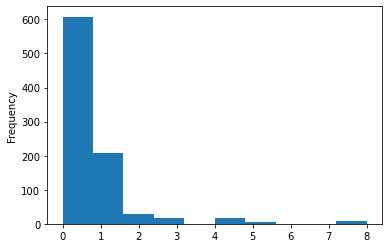

In [24]:
Titanic["SibSp"].plot.hist()

# Part 5 : Data Cleaning Or Filling The Missing Values

 **Data Cleaning**

From the data set, we notice that there are missing values in Age, Cabin ,Fare and Embarked column. We are going to replace missing values in Age with a random sample from existing ages. For Cabin, since cabin number makes little sense to the result, we are going to create a new Cabin column to indicate how many cabins the passenger has.

## Part 5.1 : Using Three Different Methods

### Part 5.1.1 : Simple Row Del Method 

In [25]:
Titanic.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [26]:
Titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

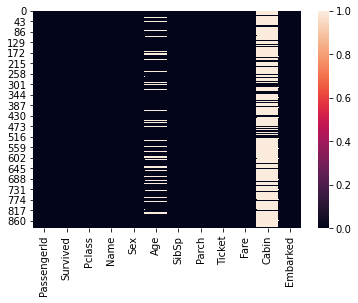

In [27]:
sns.heatmap(Titanic.isnull())

In [28]:
null_var = Titanic.isnull().sum()/Titanic.shape[0] *100
null_var

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [29]:
drop_column = null_var[null_var >20].keys()
drop_column
##null_var = Titanic_datA.isnull().sum()/Titanic_datA.shape[0] *100
#null_var

Index(['Cabin'], dtype='object')

In [30]:
#drop_column = null_var[null_var >20].keys()
#drop_column
##null_var = Titanic_datA.isnull().sum()/Titanic_datA.shape[0] *100
#null_var
N_Titanic_datA = Titanic.drop(columns = drop_column)

In [31]:
Titanic_copy = Titanic.copy()
Titanic_copy2 = Titanic.copy()
Titanic_Deep = Titanic_copy.copy()

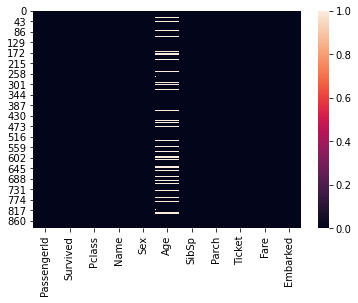

In [32]:
sns.heatmap( N_Titanic_datA.isnull())

In [33]:
N_Titanic_datA.isnull().sum()/Titanic_Deep.shape[0] *100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Embarked        0.224467
dtype: float64

In [34]:
N_Titanic_datAA = N_Titanic_datA.dropna()

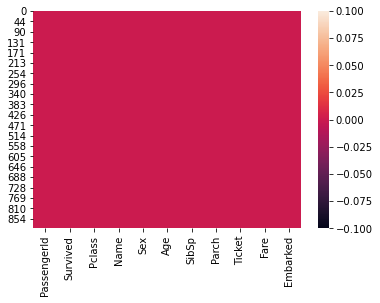

In [35]:
sns.heatmap( N_Titanic_datAA.isnull())

In [36]:
Categorical_Values = N_Titanic_datAA.select_dtypes(include=["object"]).columns
Categorical_Values_test = test.select_dtypes(include=["object"]).columns

In [37]:
Numarical_Values = N_Titanic_datAA.select_dtypes(include=['int64','float64']).columns
Numarical_Values_test = test.select_dtypes(include=['int64','float64']).columns

In [38]:
test.shape

(418, 11)

In [39]:
def cat_var_dist(var):
    return pd.concat([Titanic_Deep[var].value_counts()/Titanic_Deep.shape[0] * 100, 
          N_Titanic_datAA[var].value_counts()/N_Titanic_datAA.shape[0] * 100], axis=1,
         keys=[var+'_org', var+'clean'])
    

In [40]:
cat_var_dist("Ticket")

,Ticket_org,Ticketclean
347082,0.785634,0.983146
CA. 2343,0.785634,NaN
1601,0.785634,0.561798
347088,0.673401,0.842697
3101295,0.673401,0.842697
...,...,...
348123,0.112233,0.140449
312991,0.112233,NaN
4136,0.112233,0.140449
PC 17609,0.112233,0.140449


### Part 5.1..2 : SimpleImputer Method 

In [41]:
Imputer_mean = SimpleImputer(strategy='mean')


In [42]:
Imputer_mean.fit(Titanic_Deep[Numarical_Values])


SimpleImputer()

In [43]:
Imputer_mean.statistics_

array([4.46000000e+02, 3.83838384e-01, 2.30864198e+00, 2.96991176e+01,
       5.23007856e-01, 3.81593715e-01, 3.22042080e+01])

In [44]:
Imputer_mean.transform(Titanic_Deep[Numarical_Values])

array([[  1.    ,   0.    ,   3.    , ...,   1.    ,   0.    ,   7.25  ],
       [  2.    ,   1.    ,   1.    , ...,   1.    ,   0.    ,  71.2833],
       [  3.    ,   1.    ,   3.    , ...,   0.    ,   0.    ,   7.925 ],
       ...,
       [889.    ,   0.    ,   3.    , ...,   1.    ,   2.    ,  23.45  ],
       [890.    ,   1.    ,   1.    , ...,   0.    ,   0.    ,  30.    ],
       [891.    ,   0.    ,   3.    , ...,   0.    ,   0.    ,   7.75  ]])

In [45]:
Titanic_Deep[Numarical_Values] = Imputer_mean.transform(Titanic_Deep[Numarical_Values])
nnnn = Titanic_Deep[Numarical_Values]

In [46]:
Titanic_Deep[Numarical_Values].isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
dtype: int64

In [47]:
Imputer_mean = SimpleImputer(strategy='most_frequent')

In [48]:
Titanic_Deep[Categorical_Values] = Imputer_mean.fit_transform(Titanic_Deep[Categorical_Values])

In [49]:
Titanic_Deep[Categorical_Values].isnull().sum()

Name        0
Sex         0
Ticket      0
Embarked    0
dtype: int64

In [50]:
New_Titanic_datA = pd.concat([Titanic_Deep[Numarical_Values] , Titanic_Deep[Categorical_Values]] , axis=1)


In [51]:
New_Titanic_datA.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
Name           0
Sex            0
Ticket         0
Embarked       0
dtype: int64

### Part 5.1.3 : Mean Median and Mode Method

In [52]:
skip_column = null_var[null_var >20].keys()
skip_column


Index(['Cabin'], dtype='object')

In [53]:
Nn_Titanic_datA = Titanic_copy.drop(columns = skip_column)


In [54]:
Titanic_mean = Nn_Titanic_datA.fillna(Nn_Titanic_datA.mean())
Titanic_mean = Titanic_mean.dropna()


In [55]:
print(Titanic_mean.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [56]:
Titanic_median = Nn_Titanic_datA.fillna(Nn_Titanic_datA.median())
test_median =  test.fillna(test.median())
Titanic_median = Titanic_median.dropna()
Titanic_median.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [57]:
print("*"*30 , "Data Cleaning Using Different Method" , "*"*30)
print("*"*30 , "Simple Row Delete Mehtod" , "*"*30)
print(N_Titanic_datAA.isnull().sum())
print("*"*30 , "SimpleImputer Method" , "*"*30)
print(New_Titanic_datA.isnull().sum())
print("*"*30 , "Median" , "*"*30)
print(Titanic_median.isnull().sum())
print("*"*30 , "Mean" , "*"*30)
print(Titanic_mean.isnull().sum())

****************************** Data Cleaning Using Different Method ******************************
****************************** Simple Row Delete Mehtod ******************************
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
****************************** SimpleImputer Method ******************************
PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
Name           0
Sex            0
Ticket         0
Embarked       0
dtype: int64
****************************** Median ******************************
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
****************************** Mean **************************

# Part 6 : Finding categorical feature, Training Testing, and Accuracy Using Three Different Methods

## Part 6.1 : Simple Row Del Method

### Part 6.1.1 : Finding categorical feature

In [58]:
N_Titanic_datAA.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.125,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.000,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.000,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.750,Q


In [59]:
sex = pd.get_dummies(N_Titanic_datAA["Sex"] , drop_first=True)
sexx =  pd.get_dummies(test_median["Sex"] , drop_first=True)

In [60]:
pclass = pd.get_dummies(N_Titanic_datAA["Pclass"] , drop_first=True)
pclasss = pd.get_dummies(test_median["Pclass"] , drop_first=True)

In [61]:
embarked = pd.get_dummies(N_Titanic_datAA["Embarked"] , drop_first=True)
embarkedd = pd.get_dummies(test_median["Embarked"] , drop_first=True)

In [62]:
N_Titanic_datAA_copy = N_Titanic_datAA.copy()

In [63]:
N_Titanic_datAA_copy.drop(['Embarked', 'Pclass' ,"Sex" , "Ticket" , "Name"], axis=1 , inplace=True)

In [64]:
test_median.drop(['Embarked', 'Pclass' ,"Sex" , "Ticket" , "Name"], axis=1 , inplace=True)

In [65]:
N_Titanic_datAA_copy = pd.concat([N_Titanic_datAA_copy ,sex ,pclass ,embarked] ,axis=1)
N_Titanic_datAA_copy.head()
test_median = pd.concat([test_median ,sexx ,pclasss ,embarkedd] ,axis=1)
test_median.head()

,PassengerId,Age,SibSp,Parch,Fare,Cabin,male,2,3,Q,S
0,892,34.5,0,0,7.8292,NaN,1,0,1,1,0
1,893,47.0,1,0,7.0000,NaN,0,0,1,0,1
2,894,62.0,0,0,9.6875,NaN,1,1,0,1,0
3,895,27.0,0,0,8.6625,NaN,1,0,1,0,1
4,896,22.0,1,1,12.2875,NaN,0,0,1,0,1


In [66]:
test_median.drop(["Cabin"], axis=1 , inplace=True)

In [67]:
test1= test_median.copy()

In [68]:
test_median.head()

,PassengerId,Age,SibSp,Parch,Fare,male,2,3,Q,S
0,892,34.5,0,0,7.8292,1,0,1,1,0
1,893,47.0,1,0,7.0000,0,0,1,0,1
2,894,62.0,0,0,9.6875,1,1,0,1,0
3,895,27.0,0,0,8.6625,1,0,1,0,1
4,896,22.0,1,1,12.2875,0,0,1,0,1


### Part 6.1.2 : Training  & Testing

In [69]:
X = N_Titanic_datAA_copy.drop("Survived" , axis=1)
y = N_Titanic_datAA_copy["Survived"]

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [71]:
y.shape

(712,)

### Part 6.1.3 : Finding The Accuracy

In [72]:
#KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc_knn = round(knn.score(X_train,y_train) * 100, 2)
acc_knn

79.26

In [73]:
# Gaussian Naive Bayes

gaussian = GaussianNB()
gaussian.fit(X_train, y_train)
y_pred = gaussian.predict(X_test)
acc_gaussian = round(gaussian.score(X_train, y_train) * 100, 2)
acc_gaussian

78.38

In [74]:
# Decision Tree

decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)
acc_decision_tree = round(decision_tree.score(X_train, y_train) * 100, 2)
acc_decision_tree

100.0

In [75]:
# Random Forest

random_forest = RandomForestClassifier(n_estimators=10)
random_forest.fit(X_train, y_train)
y_pred = random_forest.predict(X_test)
random_forest.score(X_train, y_train)
acc_random_forest = round(random_forest.score(X_train, y_train) * 100, 2)
acc_random_forest

98.42

In [76]:
#LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
acc_logreg = round(logreg.score(X_train, y_train) * 100, 2)
acc_logreg

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


80.14

In [77]:
models = pd.DataFrame({
    'Model': [ 'KNN', 'Logistic Regression', 
              'Random Forest', 'Naive Bayes', 
              'Decision Tree'],
    'Score': [ acc_knn, acc_logreg, 
              acc_random_forest, acc_gaussian,
              acc_decision_tree]})
models.sort_values(by='Score', ascending=False)

,Model,Score
4,Decision Tree,100.00
2,Random Forest,98.42
1,Logistic Regression,80.14
0,KNN,79.26
3,Naive Bayes,78.38


## Part 6.2 : SimpleImputer Method

### Part 6.2.1 : Finding categorical feature

In [78]:
New_Titanic_datA.head()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Name,Sex,Ticket,Embarked
0,1.0,0.0,3.0,22.0,1.0,0.0,7.2500,"Braund, Mr. Owen Harris",male,A/5 21171,S
1,2.0,1.0,1.0,38.0,1.0,0.0,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C
2,3.0,1.0,3.0,26.0,0.0,0.0,7.9250,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,S
3,4.0,1.0,1.0,35.0,1.0,0.0,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,S
4,5.0,0.0,3.0,35.0,0.0,0.0,8.0500,"Allen, Mr. William Henry",male,373450,S


In [79]:
embarked = pd.get_dummies(New_Titanic_datA["Embarked"] , drop_first=True)
pclass = pd.get_dummies(New_Titanic_datA["Pclass"] , drop_first=True)
sex = pd.get_dummies(New_Titanic_datA["Sex"] , drop_first=True)


In [80]:
New_Titanic_datA_copy= New_Titanic_datA.copy()

In [81]:
New_Titanic_datA_copy.drop(['Embarked', 'Pclass' ,"Sex" , "Ticket" , "Name"], axis=1 , inplace=True)

In [82]:
New_Titanic_datA_copy = pd.concat([New_Titanic_datA_copy ,sex ,pclass ,embarked] ,axis=1)
New_Titanic_datA_copy.head()

,PassengerId,Survived,Age,SibSp,Parch,Fare,male,2.0,3.0,Q,S
0,1.0,0.0,22.0,1.0,0.0,7.2500,1,0,1,0,1
1,2.0,1.0,38.0,1.0,0.0,71.2833,0,0,0,0,0
2,3.0,1.0,26.0,0.0,0.0,7.9250,0,0,1,0,1
3,4.0,1.0,35.0,1.0,0.0,53.1000,0,0,0,0,1
4,5.0,0.0,35.0,0.0,0.0,8.0500,1,0,1,0,1


### Part 6.2.2 : Training & Testing

In [83]:
XXX = New_Titanic_datA_copy.drop("Survived" , axis=1)
yyy = New_Titanic_datA_copy["Survived"]

In [84]:
XXX_train, XXX_test, yyy_train, yyy_test = train_test_split(XXX, yyy, test_size=0.2, random_state=42)

### Part 6.2.3 : Finding The Accuracy

In [85]:
#KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(XXX_train, yyy_train)
yyy_pred = knn.predict(XXX_test)
acc_knn = round(knn.score(XXX_train, yyy_train) * 100, 2)
acc_knn

80.48

In [86]:
#LogisticRegression
logreg = LogisticRegression()
logreg.fit(XXX_train, yyy_train)
yyy_pred = logreg.predict(XXX_test)
acc_logreg = round(logreg.score(XXX_train, yyy_train) * 100, 2)
acc_logreg

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


81.04

In [87]:
# Random Forest

random_forest = RandomForestClassifier(n_estimators=10)
random_forest.fit(XXX_train, yyy_train)
yyy_pred = random_forest.predict(XXX_test)
random_forest.score(XXX_train, yyy_train)
acc_random_forest = round(random_forest.score(XXX_train, yyy_train) * 100, 2)
acc_random_forest

97.89

In [88]:
# Gaussian Naive Bayes

gaussian = GaussianNB()
gaussian.fit(XXX_train, yyy_train)
yyy_pred = gaussian.predict(XXX_test)
acc_gaussian = round(gaussian.score(XXX_train, yyy_train) * 100, 2)
acc_gaussian

80.76

In [89]:
# Decision Tree

decision_tree = DecisionTreeClassifier()
decision_tree.fit(XXX_train, yyy_train)
yyy_pred = decision_tree.predict(XXX_test)
acc_decision_tree = round(decision_tree.score(XXX_train, yyy_train) * 100, 2)
acc_decision_tree

100.0

In [90]:
models = pd.DataFrame({
    'Model': [ 'KNN', 'Logistic Regression', 
              'Random Forest', 'Naive Bayes', 
              'Decision Tree'],
    'Score': [ acc_knn, acc_logreg, 
              acc_random_forest, acc_gaussian,
              acc_decision_tree]})
models.sort_values(by='Score', ascending=False)

,Model,Score
4,Decision Tree,100.00
2,Random Forest,97.89
1,Logistic Regression,81.04
3,Naive Bayes,80.76
0,KNN,80.48


## Part 6.3 : Mean Median and Mode Method

### Part 6.3.1 : Finding categorical feature

In [91]:
Titanic_median.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [92]:
embarked = pd.get_dummies(Titanic_median["Embarked"] , drop_first=True)
pclass = pd.get_dummies(Titanic_median["Pclass"] , drop_first=True)
sex = pd.get_dummies(Titanic_median["Sex"] , drop_first=True)


In [93]:
Titanic_median_copy= Titanic_median.copy()

In [94]:
Titanic_median_copy.drop(['Embarked', 'Pclass' ,"Sex" , "Ticket" , "Name"], axis=1 , inplace=True)



In [95]:
Titanic_median_copy = pd.concat([Titanic_median_copy ,sex ,pclass ,embarked] ,axis=1)
Titanic_median_copy.head()

,PassengerId,Survived,Age,SibSp,Parch,Fare,male,2,3,Q,S
0,1,0,22.0,1,0,7.2500,1,0,1,0,1
1,2,1,38.0,1,0,71.2833,0,0,0,0,0
2,3,1,26.0,0,0,7.9250,0,0,1,0,1
3,4,1,35.0,1,0,53.1000,0,0,0,0,1
4,5,0,35.0,0,0,8.0500,1,0,1,0,1


### Part 6.3.2 : Training &Testing

In [96]:
XX = Titanic_median_copy.drop("Survived" , axis=1)
yy = Titanic_median_copy["Survived"]

In [97]:
XXX_train, XXX_test, yyy_train, yyy_test = train_test_split(XX, yy, test_size=0.2, random_state=42)

In [98]:
XXX_train.shape

(711, 10)

### Part 6.3.3 : Finding The Accuracy

In [99]:
#KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(XXX_train, yyy_train)
yyy_pred = knn.predict(XXX_test)
acc_knn = round(knn.score(XXX_train, yyy_train) * 100, 2)
acc_knn

79.75

In [100]:
# Gaussian Naive Bayes

gaussian = GaussianNB()
gaussian.fit(XXX_train, yyy_train)
yyy_pred = gaussian.predict(XXX_test)
acc_gaussian = round(gaussian.score(XXX_train, yyy_train) * 100, 2)
acc_gaussian

80.17

In [101]:
# Decision Tree

decision_tree = DecisionTreeClassifier()
decision_tree.fit(XXX_train, yyy_train)
yyy_pred = decision_tree.predict(XXX_test)
acc_decision_tree = round(decision_tree.score(XXX_train, yyy_train) * 100, 2)
acc_decision_tree

100.0

In [102]:
# Random Forest

random_forest = RandomForestClassifier(n_estimators=10)
random_forest.fit(XXX_train, yyy_train)
yyy_pred = random_forest.predict(XXX_test)
random_forest.score(XXX_train, yyy_train)
acc_random_forest = round(random_forest.score(XXX_train, yyy_train) * 100, 2)
acc_random_forest

98.45

In [103]:
#LogisticRegression
logreg = LogisticRegression()
logreg.fit(XXX_train, yyy_train)
yyy_pred = logreg.predict(XXX_test)
acc_logreg = round(logreg.score(XXX_train, yyy_train) * 100, 2)
acc_logreg

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


80.03

In [104]:
models = pd.DataFrame({
    'Model': [ 'KNN', 'Logistic Regression', 
              'Random Forest', 'Naive Bayes', 
              'Decision Tree'],
    'Score': [ acc_knn, acc_logreg, 
              acc_random_forest, acc_gaussian,
              acc_decision_tree]})
models.sort_values(by='Score', ascending=False)

,Model,Score
4,Decision Tree,100.00
2,Random Forest,98.45
3,Naive Bayes,80.17
1,Logistic Regression,80.03
0,KNN,79.75


In [105]:
test_median.isnull().sum()

PassengerId    0
Age            0
SibSp          0
Parch          0
Fare           0
male           0
2              0
3              0
Q              0
S              0
dtype: int64

In [106]:
# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

gbk = GradientBoostingClassifier()

from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier()
from sklearn.linear_model import Perceptron

perceptron = Perceptron()
from sklearn.svm import LinearSVC

linear_svc = LinearSVC()
from sklearn.svm import SVC

svc = SVC()


In [107]:
# Gradient Boosting Classifier
gbkk = GradientBoostingClassifier()
gbkk.fit(X_train, y_train)
gbk_pred = gbkk.predict(X_test)
acc_gbkk = round(gbkk.score(X_train, y_train) * 100, 2)
predictions = gbkk.predict(test_median)
acc_gbkk

92.44

In [108]:
gbk_pred = gbkk.predict(X_test)
gbk_pred

array([1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0])

In [109]:
sgd.fit(XXX_train, yyy_train)
yyy_pred = sgd.predict(XXX_test)
acc_gbk = round(sgd.score(XXX_train, yyy_train) * 100, 2)
acc_gbk

63.85

In [110]:
perceptron.fit(XXX_train, yyy_train)
yyy_pred = perceptron.predict(XXX_test)
acc_gbk = round(perceptron.score(XXX_train, yyy_train) * 100, 2)
acc_gbk

61.88

In [111]:
linear_svc.fit(XXX_train, yyy_train)
yyy_pred = linear_svc.predict(XXX_test)
acc_gbk = round(linear_svc.score(XXX_train, yyy_train) * 100, 2)
acc_gbk

/opt/conda/lib/python3.7/site-packages/sklearn/svm/_base.py:977: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


51.62

In [112]:
svc.fit(XXX_train, yyy_train)
yyy_pred = svc.predict(XXX_test)
acc_gbk = round(svc.score(XXX_train, yyy_train) * 100, 2)
acc_gbk

64.84

In [113]:
#set ids as PassengerId and predict survival 
ids = test1['PassengerId']
predictions = gbkk.predict(test_median)

#set the output as a dataframe and convert to csv file named submission.csv
output = pd.DataFrame({ 'PassengerId' : ids, 'Survived': predictions })
output.to_csv('submission.csv', index=False)